In [1]:
original_root='MPI Images Selected'
sorted_root='rr'
classes_names=['Normal', 'Ischemia', 'Infarction']

In [2]:
from PIL import Image

def crop_image(image_path, top_pixels_to_crop=0, bottom_pixels_to_crop=0, left_pixels_to_crop=0, right_pixels_to_crop=0, save_path=None):
   
    img = Image.open(image_path)
    width, height = img.size

    
    new_top = top_pixels_to_crop
    new_bottom = height - bottom_pixels_to_crop
    new_left = left_pixels_to_crop
    new_right = width - right_pixels_to_crop

    
    new_top = max(new_top, 0)
    new_bottom = max(new_bottom, new_top)
    new_left = max(new_left, 0)
    new_right = max(new_right, new_left)

   
    cropped_img = img.crop((new_left, new_top, new_right, new_bottom))

   
    if save_path:
        cropped_img.save(save_path)
    
    return cropped_img

In [3]:
import os
import shutil
import random

def create_train_val_test_split(
    source_root=original_root,
    target_root=sorted_root,
    classes=classes_names,
    split=(0.6, 0.2, 0.2),
    seed=43
):
    assert sum(split) == 1.0, "Split percentages must sum to 1.0"
    random.seed(seed)

    
    split_names = ['train', 'val', 'test']
    for split_name in split_names:
        for cls in classes:
            os.makedirs(os.path.join(target_root, split_name, cls), exist_ok=True)

   
    for cls in classes:
        
        matching_folders = [
            f for f in os.listdir(source_root)
            if os.path.isdir(os.path.join(source_root, f)) and cls.lower() in f.lower()
        ]

        random.shuffle(matching_folders)
        total = len(matching_folders)

        n_train = int(split[0] * total)
        n_val = int(split[1] * total)

        train_folders = matching_folders[:n_train]
        val_folders = matching_folders[n_train:n_train + n_val]
        test_folders = matching_folders[n_train + n_val:]

        split_map = {
            'train': train_folders,
            'val': val_folders,
            'test': test_folders
        }

        for split_name, folders in split_map.items():
            for folder in folders:
                src_folder = os.path.join(source_root, folder)
                dst_folder = os.path.join(target_root, split_name, cls)

                for file in os.listdir(src_folder):
                    
                    if any(sub in file.lower() for sub in ['display', 'nac','segments']):
                        continue
                    src_file = os.path.join(src_folder, file)
                    dst_file = os.path.join(dst_folder, f"{folder}_{file}")
                    crop_image(src_file,right_pixels_to_crop=324,save_path=dst_file)
                   
    print("✅ Dataset split completed!")


In [55]:
create_train_val_test_split()
    

✅ Dataset split completed!


In [4]:
import os

def count_images_in_class(class_name, root_dir=sorted_root):
    total_count = 0
    count_list_foreach_split_plus_total_count=[]
    for split in ['train','val','test']:
        class_dir = os.path.join(root_dir, split, class_name)
        if os.path.exists(class_dir):
            num_images = len([
                f for f in os.listdir(class_dir)
                if os.path.isfile(os.path.join(class_dir, f))
            ])
            print(f"{split}/{class_name}: {num_images} images")
            count_list_foreach_split_plus_total_count.append(num_images)
            total_count += num_images
        else:
            print(f"{split}/{class_name} folder not found.")
    print(f"🔢 Total {class_name} images: {total_count}")
    count_list_foreach_split_plus_total_count.append(total_count)
    return count_list_foreach_split_plus_total_count



In [5]:
def images_count_report_for_classes():
    for class_name in classes_names:
        count_images_in_class(class_name)
  

In [58]:
images_count_report_for_classes()  

train/Normal: 157 images
val/Normal: 38 images
test/Normal: 66 images
🔢 Total Normal images: 261
train/Ischemia: 43 images
val/Ischemia: 12 images
test/Ischemia: 24 images
🔢 Total Ischemia images: 79
train/Infarction: 13 images
val/Infarction: 3 images
test/Infarction: 6 images
🔢 Total Infarction images: 22


In [61]:
import os
import shutil
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img


train_base = os.path.join(sorted_root,'train') 
classes_to_augment = classes_names
target_count = count_images_in_class('normal')[0] #gets train/normal count 


augmentor = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,              
    zoom_range=0.25,                
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    brightness_range=(0.7, 1.3),   
    shear_range=10,      
    fill_mode='nearest'
)


for class_name in classes_to_augment:
    class_dir = os.path.join(train_base, class_name)
    
    images = [f for f in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, f)) and f.lower().endswith(('.bmp', '.png', '.jpg', '.jpeg'))]

    current_count = len(images)
    print(f"Augmenting {class_name}: currently {current_count} images.")

    i = 0
    while len(os.listdir(class_dir)) < target_count:
        img_path = os.path.join(class_dir, images[i % current_count])
        image = load_img(img_path, target_size=(224, 224))
        image_array = img_to_array(image)
        image_array = image_array.reshape((1,) + image_array.shape)

        
        for batch in augmentor.flow(image_array, batch_size=1, save_to_dir=class_dir,
                                    save_prefix='aug', save_format='jpeg'):
            break  

        i += 1

print("✅ Oversampling complete.")


train/normal: 157 images
val/normal: 38 images
test/normal: 66 images
🔢 Total normal images: 261
Augmenting Normal: currently 157 images.
Augmenting Ischemia: currently 43 images.
Augmenting Infarction: currently 13 images.
✅ Oversampling complete.


In [30]:



import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
import os

base_dir = sorted_root
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

image_size = (224, 224)
batch_size = 16
num_classes = 3
learning_rate = 1e-4

train_datagen = ImageDataGenerator(rescale=1./255)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

for layer in base_model.layers[:-10]:
    layer.trainable = False
for layer in base_model.layers[-10:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
x = Dropout(0.5)(x)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax', kernel_regularizer=l2(0.001))(x)

model = Model(inputs=base_model.input, outputs=output)

import tensorflow as tf


def custom_ischemia_loss(weight=2.0):
    def loss(y_true, y_pred):
        base_loss = tf.keras.losses.categorical_crossentropy(y_true, y_pred)

       
        true_ischemia = tf.cast(tf.equal(tf.argmax(y_true, axis=1), 1), tf.float32)  # index 1 = ischemia
        pred_normal = tf.cast(tf.equal(tf.argmax(y_pred, axis=1), 0), tf.float32)    # index 0 = normal

        penalty_mask = true_ischemia * pred_normal
        penalty = weight * penalty_mask

        return base_loss + penalty
    return loss


model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss=custom_ischemia_loss(weight=3.0),
              metrics=['accuracy'])




early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1)
lr_reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)

from sklearn.utils.class_weight import compute_class_weight




history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[early_stop, lr_reduce]
)

test_loss, test_acc = model.evaluate(test_generator)
print(f"✅ Test accuracy: {test_acc:.2f}")


Found 471 images belonging to 3 classes.
Found 53 images belonging to 3 classes.
Found 96 images belonging to 3 classes.
Epoch 1/50
30/30 [==============================] - 17s 398ms/step - loss: 2.5309 - accuracy: 0.3864 - val_loss: 1.3234 - val_accuracy: 0.6415 - lr: 1.0000e-04
Epoch 2/50
30/30 [==============================] - 10s 345ms/step - loss: 1.8707 - accuracy: 0.4968 - val_loss: 1.2259 - val_accuracy: 0.5849 - lr: 1.0000e-04
Epoch 3/50
30/30 [==============================] - 10s 346ms/step - loss: 1.5168 - accuracy: 0.6221 - val_loss: 1.0592 - val_accuracy: 0.7170 - lr: 1.0000e-04
Epoch 4/50
30/30 [==============================] - 10s 341ms/step - loss: 1.2497 - accuracy: 0.7176 - val_loss: 1.0040 - val_accuracy: 0.6981 - lr: 1.0000e-04
Epoch 5/50
30/30 [==============================] - 10s 346ms/step - loss: 1.2174 - accuracy: 0.7070 - val_loss: 0.9720 - val_accuracy: 0.7170 - lr: 1.0000e-04
Epoch 6/50
30/30 [==============================] - 10s 349ms/step - loss: 1.07

6/6 [==============================] - 3s 289ms/step


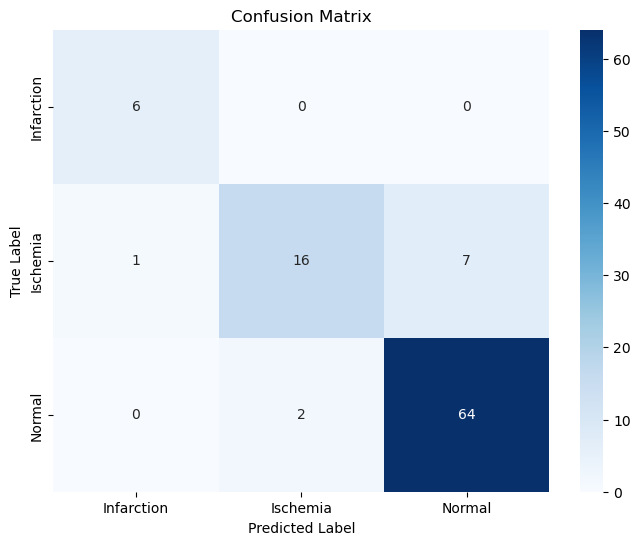

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator


test_labels = test_generator.classes
predictions = model.predict(test_generator, verbose=1)
predicted_labels = np.argmax(predictions, axis=1)


cm = confusion_matrix(test_labels, predicted_labels)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [34]:
from sklearn.metrics import classification_report


test_labels = test_generator.classes
predictions = model.predict(test_generator, verbose=1)
predicted_labels = np.argmax(predictions, axis=1)


report = classification_report(test_labels, predicted_labels, target_names=test_generator.class_indices.keys())
print(report)


6/6 [==============================] - 2s 288ms/step
              precision    recall  f1-score   support

  Infarction       0.86      1.00      0.92         6
    Ischemia       0.89      0.67      0.76        24
      Normal       0.90      0.97      0.93        66

    accuracy                           0.90        96
   macro avg       0.88      0.88      0.87        96
weighted avg       0.90      0.90      0.89        96



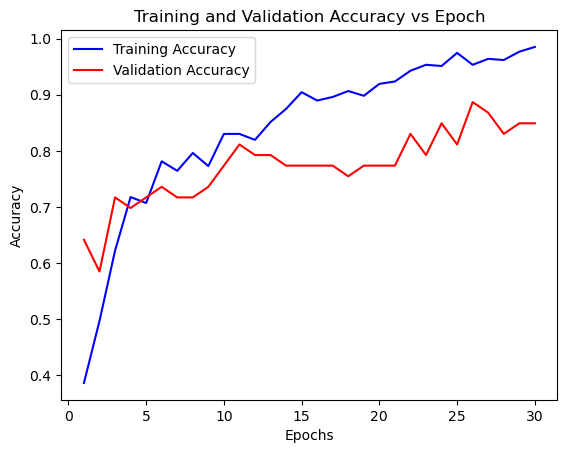

In [33]:
import matplotlib.pyplot as plt


history_dict = history.history
acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']

epochs = range(1, len(acc_values) + 1)

plt.plot(epochs, acc_values, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc_values, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


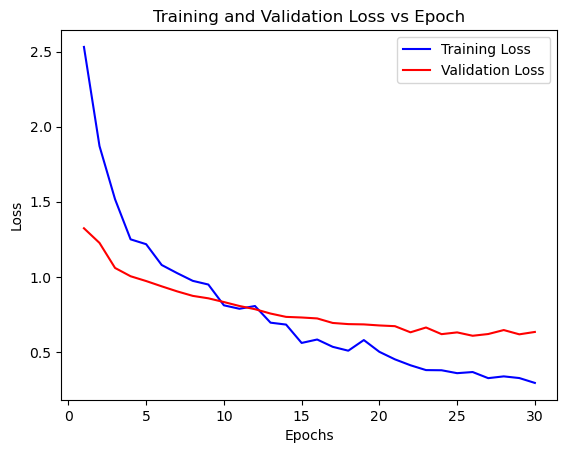

In [32]:
import matplotlib.pyplot as plt


history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']

epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, 'b', label='Training Loss')
plt.plot(epochs, val_loss_values, 'r', label='Validation Loss')
plt.title('Training and Validation Loss vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
